In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans

## 請安裝
> pip install opencv-python

# Problem : K-Means Clustering
**K-Means Clustering** is an unsupervised learning algorithm for data grouping. In image segmen- tation, it can be applied to partition image pixels into different groups based on the associated pixel values or features. In this problem, you will learn how to segment the provided image by using K-means clustering.

In [2]:
img = cv2.imread('data/bird.jpg')
#通常使用RGB為順序，但CV2引入資料時順序是BGR，所以須轉換
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## 1-1. cluster with only RGB values

In [3]:
#自己寫一個Kmeans，輸入原始資料以及K值，即可獲得群數和中心值
def km_clust(array, n_clusters):   
    # Define the k-means clustering problem
    k_m = KMeans(n_clusters = n_clusters)
    # Solve the k-means clustering problem
    k_m.fit(array)
    # Get the coordinates of the clusters centres
    center = k_m.cluster_centers_
    # Get the label of each point
    label = k_m.labels_
    return(label, center)

In [4]:
h, w, c = img.shape
print(img.shape)
Z = img.reshape((-1,3)) #row=合併前兩維度(長寬pixel，-1降維度)，col=3(RGB)
Z.shape

(1024, 1024, 3)


(1048576, 3)

In [13]:
K = 2
label, center = km_clust(Z,K)
#center print出來是
# [[107.6958206, 95.56751108, 71.60331411]
#  [163.22627536,197.72436505,120.58396853]]
#要讓它變成整數
center = np.uint8(center[:,:3])
center

C:\Users\jocel\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([[163, 197, 120],
       [107,  95,  71]], dtype=uint8)

In [14]:
#label.shape結果為(1048576,)，本身就已經是1維，所以不需要再做flatten(保險起見，這邊還是會做)
#將label帶入center，若label為0，則帶入[163, 197, 120]，若label為1，則帶入[107,  95,  71]]
res = center[label.flatten()]
# res是二維，要將他重塑成原始的形狀
res = res.reshape(img.shape)

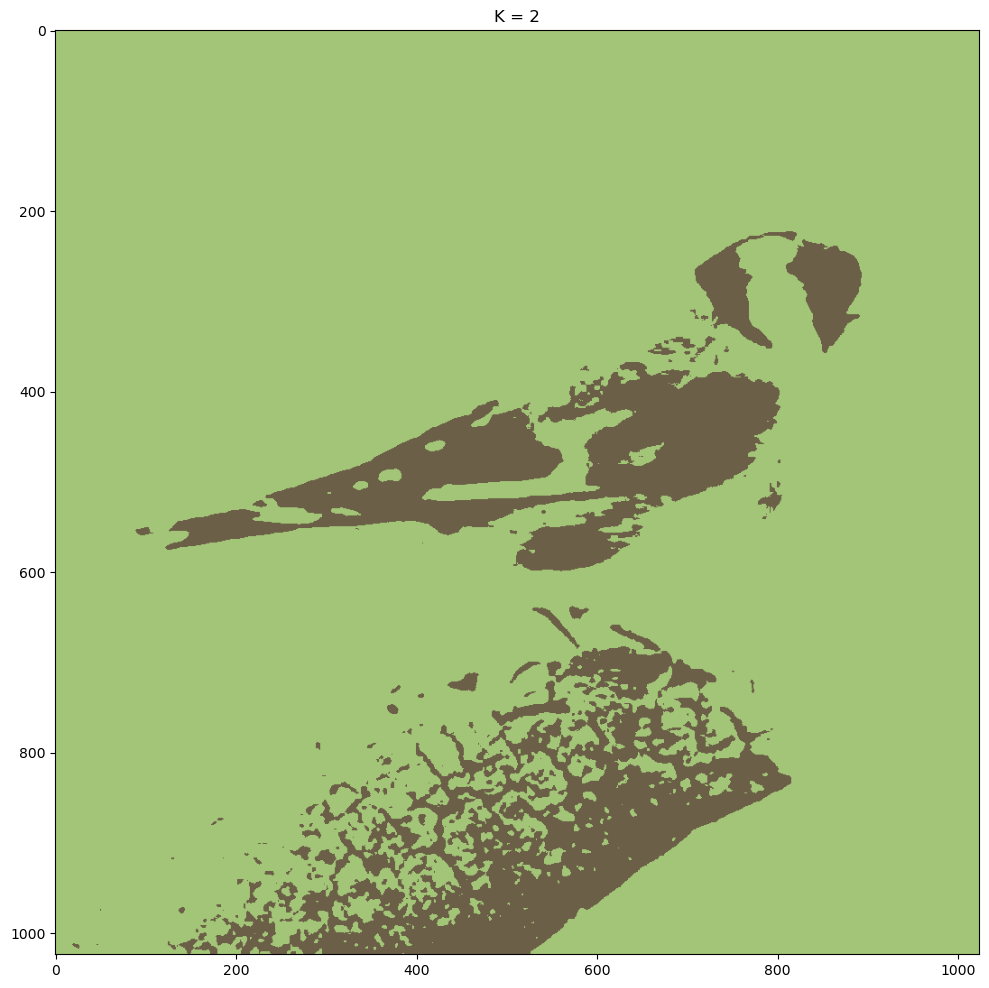

In [12]:
plt.figure(figsize=(16,12))
plt.title("K = {}".format(K))
plt.imshow(res)

## 1-2. cluster with RGB values and the location

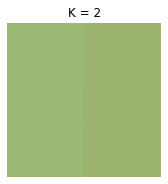

In [25]:
#上面的影像處理只包含顏色就別人加上位置，因此程式碼都一樣，只加上location

#開始處理影像

#首先查看img的維度
h, w, c = img.shape

#Added location feature
Z = np.zeros((h, w, c+2)) #最後一個維度要記錄RGB和高寬位置，所以C+2
for h in range(len(img)): #高row
    for w in range(len(img[h])): #寬col
        Z[h][w] = np.append(img[h][w], [[h], [w]]) #append img pixel RGB以及高寬位置
Z = Z.reshape(-1, 5) #重塑後shape(h*w,5)

Ks = [2,4,8,16,32]
plt.figure(figsize=(16,12))

for i, K in enumerate(Ks):
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape((img.shape))

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()

## 1-3. explain the differences between the two methods under the same K.
![](images/7.4_result.PNG)

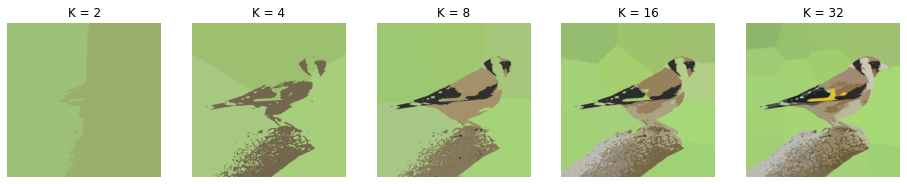

In [29]:
#RGB 值範圍是 0 到 255，而位置特徵的數值是數百數千，導致位置特徵對 KMeans 分群的影響過大。因此將位置特徵除以4，使其和RBG數值接近，在分群中有更平衡的權重。
h, w, c = img.shape

Z = np.zeros((h, w, c+2))
for h in range(len(img)):
    for w in range(len(img[h])):
        Z[h][w] = np.append(img[h][w], [[h/4], [w/4]])  #重點在這行，要除以四
Z = Z.reshape(-1, 5)

Ks = [2,4,8,16,32]
plt.figure(figsize=(16,12))

for i, K in enumerate(Ks):
    label, center = km_clust(Z, K)

    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape((img.shape))

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()